In [5]:
import pandas as pd

df = pd.read_excel("C:/Users/HP/Downloads/E Commerce Dataset.xlsx", sheet_name="E Comm")

In [6]:
df.head()

,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [7]:
df.shape

(5630, 20)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   str    
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   str    
 7   Gender                       5630 non-null   str    
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   str    
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   str    
 13  NumberOfAddress              

In [9]:
# find out the missing columns
df.isna().sum()

CustomerID                       0
Churn                            0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
dtype: int64

In [10]:
# percentage of missing values
df.isna().sum()/ len(df) * 100

CustomerID                     0.000000
Churn                          0.000000
Tenure                         4.689165
PreferredLoginDevice           0.000000
CityTier                       0.000000
WarehouseToHome                4.458259
PreferredPaymentMode           0.000000
Gender                         0.000000
HourSpendOnApp                 4.529307
NumberOfDeviceRegistered       0.000000
PreferedOrderCat               0.000000
SatisfactionScore              0.000000
MaritalStatus                  0.000000
NumberOfAddress                0.000000
Complain                       0.000000
OrderAmountHikeFromlastYear    4.706927
CouponUsed                     4.547069
OrderCount                     4.582593
DaySinceLastOrder              5.452931
CashbackAmount                 0.000000
dtype: float64

In [11]:
# as the percent of missing values in columns is around 4.5% we need to impute them with the median of those columns
missing_cols = ['Tenure','WarehouseToHome','HourSpendOnApp','OrderAmountHikeFromlastYear','CouponUsed',
                'OrderCount','DaySinceLastOrder']

for col in missing_cols:
    df[col]= df[col].fillna(df[col].median())

In [12]:
df.isna().sum()

CustomerID                     0
Churn                          0
Tenure                         0
PreferredLoginDevice           0
CityTier                       0
WarehouseToHome                0
PreferredPaymentMode           0
Gender                         0
HourSpendOnApp                 0
NumberOfDeviceRegistered       0
PreferedOrderCat               0
SatisfactionScore              0
MaritalStatus                  0
NumberOfAddress                0
Complain                       0
OrderAmountHikeFromlastYear    0
CouponUsed                     0
OrderCount                     0
DaySinceLastOrder              0
CashbackAmount                 0
dtype: int64

In [13]:
# check for duplicate values
df.duplicated().sum()

np.int64(0)

# EDA

In [14]:
# Churn Rate
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True).mul(100)

Churn
0    83.161634
1    16.838366
Name: proportion, dtype: float64

In [15]:
# Compare churn with different numeric columns
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('CustomerID')
numeric_cols.remove('Churn')

df.groupby('Churn')[numeric_cols].mean()

,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
Churn,,,,,,,,,,,,,
0,11.404528,1.619821,15.305639,2.928663,3.639257,3.001282,4.162965,0.234088,15.686032,1.718069,2.992952,4.709739,180.635203
1,3.859705,1.827004,16.856540,2.964135,3.934599,3.390295,4.466245,0.535865,15.618143,1.710970,2.808017,3.222574,160.370928


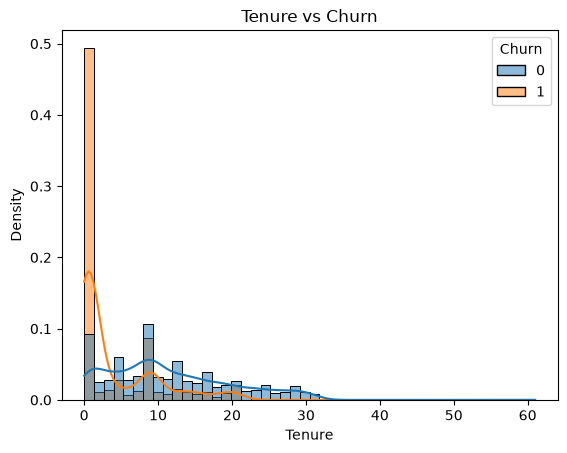

In [17]:
# Visualizing the Distribution

import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data=df, x = 'Tenure', hue = 'Churn', kde=True, stat='density',common_norm=False)
plt.title('Tenure vs Churn')
plt.show()

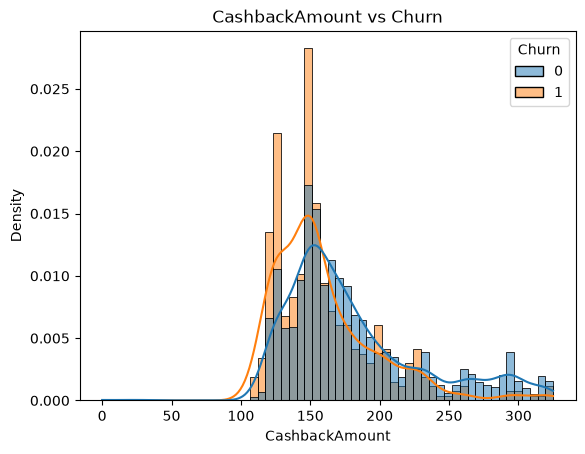

In [18]:
sns.histplot(data=df, x='CashbackAmount', hue='Churn', kde=True, stat='density', common_norm=False)
plt.title('CashbackAmount vs Churn')
plt.show()

In [19]:
df.columns

Index(['CustomerID', 'Churn', 'Tenure', 'PreferredLoginDevice', 'CityTier',
       'WarehouseToHome', 'PreferredPaymentMode', 'Gender', 'HourSpendOnApp',
       'NumberOfDeviceRegistered', 'PreferedOrderCat', 'SatisfactionScore',
       'MaritalStatus', 'NumberOfAddress', 'Complain',
       'OrderAmountHikeFromlastYear', 'CouponUsed', 'OrderCount',
       'DaySinceLastOrder', 'CashbackAmount'],
      dtype='str')

In [20]:
df.groupby('PreferredLoginDevice')['Churn'].mean()

PreferredLoginDevice
Computer        0.198286
Mobile Phone    0.125859
Phone           0.224208
Name: Churn, dtype: float64

In [21]:
df.groupby('PreferedOrderCat')['Churn'].mean()


PreferedOrderCat
Fashion               0.154964
Grocery               0.048780
Laptop & Accessory    0.102439
Mobile                0.271941
Mobile Phone          0.275374
Others                0.075758
Name: Churn, dtype: float64

In [22]:
df.groupby('MaritalStatus')['Churn'].mean()


MaritalStatus
Divorced    0.146226
Married     0.115204
Single      0.267261
Name: Churn, dtype: float64

In [23]:
df.groupby('Gender')['Churn'].mean()

Gender
Female    0.154942
Male      0.177305
Name: Churn, dtype: float64

In [24]:
# as there both mobile phone and phone as separate categories we need to change that and standardize it accordingly.

In [25]:
df['PreferredLoginDevice'].unique()


<StringArray>
['Mobile Phone', 'Phone', 'Computer']
Length: 3, dtype: str

In [26]:
df['PreferedOrderCat'].unique()

<StringArray>
['Laptop & Accessory', 'Mobile', 'Mobile Phone', 'Others', 'Fashion',
 'Grocery']
Length: 6, dtype: str

In [27]:
df['PreferredPaymentMode'].unique()

<StringArray>
['Debit Card', 'UPI', 'CC', 'Cash on Delivery', 'E wallet', 'COD',
 'Credit Card']
Length: 7, dtype: str

In [28]:
df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({'COD': 'Cash on Delivery'})

In [29]:
 # now replace the value in the specific columns
df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace({'Phone': 'Mobile Phone'})

In [30]:
df['PreferedOrderCat'] = df['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})


In [31]:
df['PreferredLoginDevice'].unique()

<StringArray>
['Mobile Phone', 'Computer']
Length: 2, dtype: str

In [32]:
df['PreferedOrderCat'].unique()


<StringArray>
['Laptop & Accessory', 'Mobile Phone', 'Others', 'Fashion', 'Grocery']
Length: 5, dtype: str

In [33]:
df.groupby('PreferredLoginDevice')['Churn'].mean()

PreferredLoginDevice
Computer        0.198286
Mobile Phone    0.156156
Name: Churn, dtype: float64

In [34]:
df.groupby('PreferedOrderCat')['Churn'].mean()

PreferedOrderCat
Fashion               0.154964
Grocery               0.048780
Laptop & Accessory    0.102439
Mobile Phone          0.274038
Others                0.075758
Name: Churn, dtype: float64

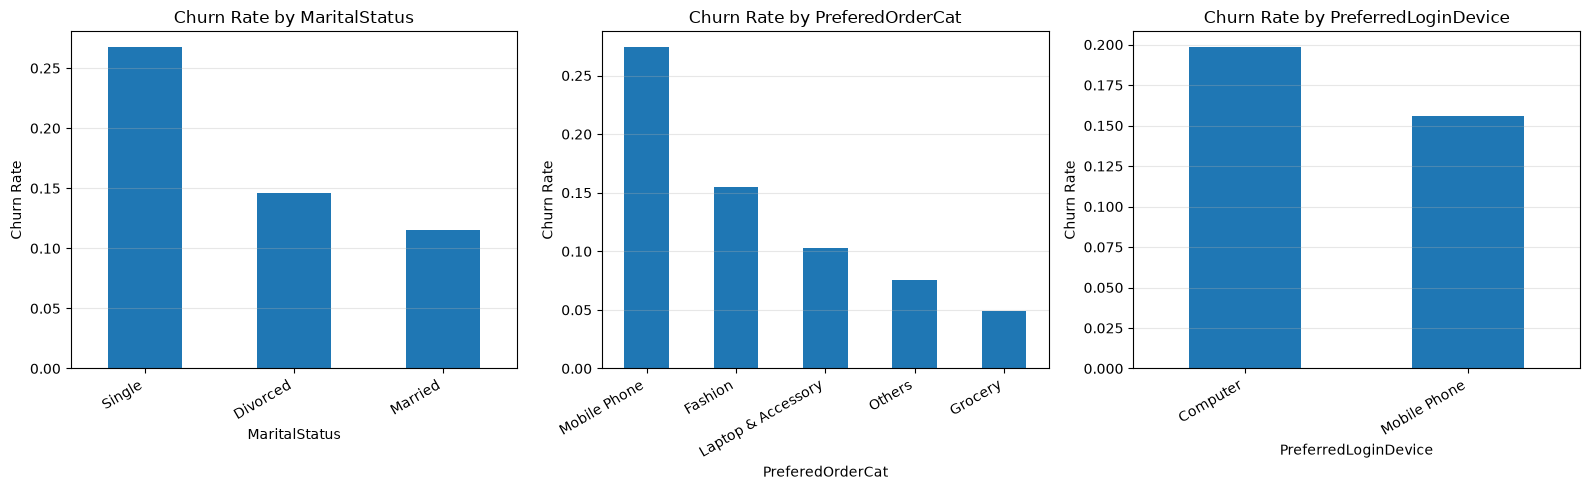

In [66]:
import matplotlib.pyplot as plt

# --- Compute churn rates, sorted descending ---
marital_churn = df.groupby('MaritalStatus')['Churn'].mean().sort_values(ascending=False)
order_cat_churn = df.groupby('PreferedOrderCat')['Churn'].mean().sort_values(ascending=False)
device_churn = df.groupby('PreferredLoginDevice')['Churn'].mean().sort_values(ascending=False)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

marital_churn.plot(kind='bar', ax=axes[0])
axes[0].set_title('Churn Rate by MaritalStatus')
axes[0].set_xlabel('MaritalStatus')
axes[0].set_ylabel('Churn Rate')

order_cat_churn.plot(kind='bar', ax=axes[1])
axes[1].set_title('Churn Rate by PreferedOrderCat')
axes[1].set_xlabel('PreferedOrderCat')
axes[1].set_ylabel('Churn Rate')

device_churn.plot(kind='bar', ax=axes[2])
axes[2].set_title('Churn Rate by PreferredLoginDevice')
axes[2].set_xlabel('PreferredLoginDevice')
axes[2].set_ylabel('Churn Rate')

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# Preparing the data for prediction model

In [35]:
# Starting with encoding the as there are columns that are objects

categorical_cols = df.select_dtypes(include ='str').columns.tolist()
print(categorical_cols)

['PreferredLoginDevice', 'PreferredPaymentMode', 'Gender', 'PreferedOrderCat', 'MaritalStatus']


In [36]:
df_encoded =  pd.get_dummies(df, columns = categorical_cols, drop_first = True)
df_encoded.shape

(5630, 28)

In [37]:
 df_encoded.head()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,...,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,50001,1,4.0,3,6.0,3.0,3,2,9,1,...,True,False,False,False,False,True,False,False,False,True
1,50002,1,9.0,1,8.0,3.0,4,3,7,1,...,False,False,True,True,False,False,True,False,False,True
2,50003,1,9.0,1,30.0,2.0,4,3,6,1,...,True,False,False,True,False,False,True,False,False,True
3,50004,1,0.0,3,15.0,2.0,4,5,8,0,...,True,False,False,True,False,True,False,False,False,True
4,50005,1,0.0,1,12.0,3.0,3,5,3,0,...,False,False,False,True,False,False,True,False,False,True


In [39]:
# now we need to split the dataset in two ie. training set and test set
from sklearn.model_selection import train_test_split

X = df_encoded.drop(columns=['CustomerID', 'Churn'])
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [40]:
print(X.shape, y.shape)
print(y_train.mean(), y_test.mean())

(5630, 26) (5630,)
0.16829484902309058 0.16873889875666073


In [41]:
# training and testing on the logistic regression model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state = 42)
model.fit(X_train, y_train)

C:\Users\HP\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [42]:
y_pred = model.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8925399644760214

In [44]:
# Let try after scaling the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [45]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
accuracy_score(y_test, y_pred)

0.8960923623445826

In [74]:
# As accuracy cannot be trusted alone we need to go check confusion matrix, precision, and recall

from sklearn.metrics import confusion_matrix, classification_report

cm_lr = confusion_matrix(y_test, y_pred)
print(cm_lr)

[[905  31]
 [ 86 104]]


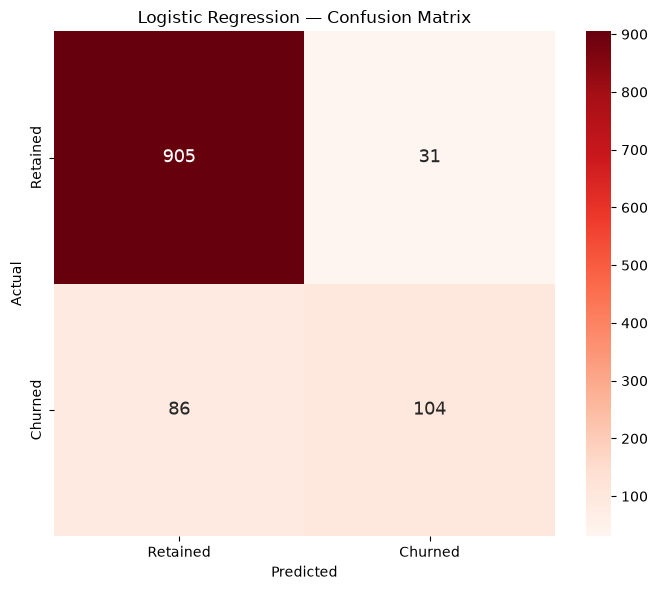

In [90]:
cm_lr = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Reds',
    xticklabels=['Retained', 'Churned'],
    yticklabels=['Retained', 'Churned'],
    cbar=True,
    annot_kws={'size': 13}
)

plt.title('Logistic Regression — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [47]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.97      0.94       936
           1       0.77      0.55      0.64       190

    accuracy                           0.90      1126
   macro avg       0.84      0.76      0.79      1126
weighted avg       0.89      0.90      0.89      1126



In [48]:
# As these numbers are way off the accuracy score of logistic regression lets try a different model
# Random Forrest Tree Model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[932   4]
 [ 35 155]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       936
           1       0.97      0.82      0.89       190

    accuracy                           0.97      1126
   macro avg       0.97      0.91      0.93      1126
weighted avg       0.97      0.97      0.96      1126



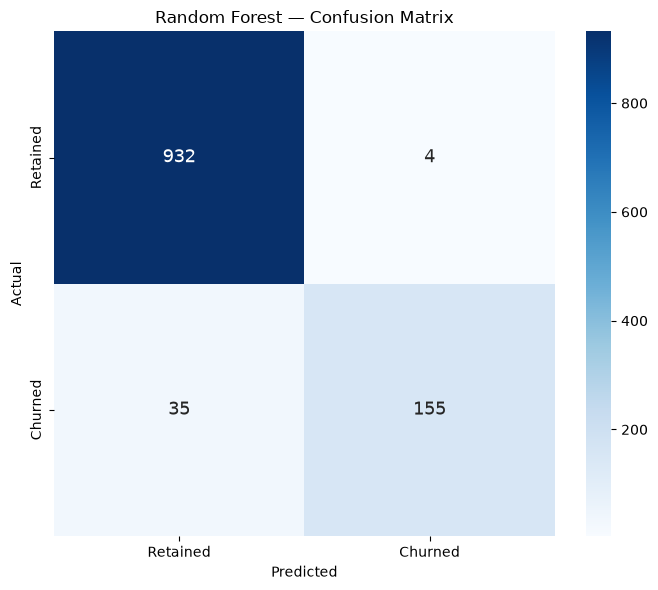

In [87]:
# ploting confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Retained', 'Churned'],
    yticklabels=['Retained', 'Churned'],
    cbar=True,
    annot_kws={'size': 13}
)

plt.title('Random Forest — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [49]:
# features the random forrest model gave importance

importances = pd.Series(rf_model.feature_importances_, index = X_test.columns)
importances.sort_values(ascending = False).head(10)

Tenure                         0.229290
CashbackAmount                 0.101350
Complain                       0.069824
WarehouseToHome                0.069302
NumberOfAddress                0.062732
DaySinceLastOrder              0.056401
OrderAmountHikeFromlastYear    0.055155
SatisfactionScore              0.047200
NumberOfDeviceRegistered       0.034582
OrderCount                     0.029520
dtype: float64

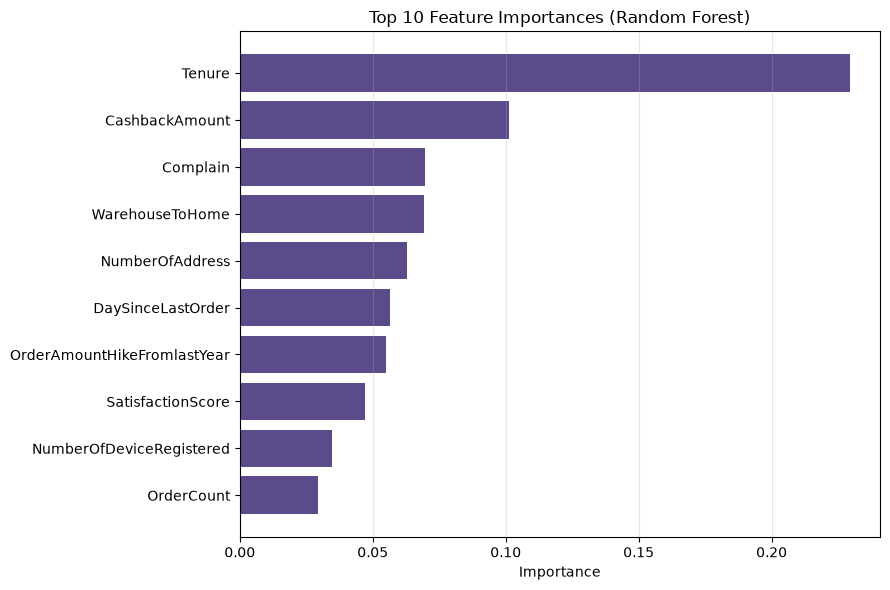

In [105]:
importances = pd.Series(rf_model.feature_importances_, index=X_test.columns)
top10 = importances.sort_values(ascending=True).tail(10)

plt.figure(figsize=(9, 6))
plt.barh(top10.index, top10.values, color='#5B4B8A')

plt.title('Top 10 Feature Importances (Random Forest)')
plt.xlabel('Importance')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
# Gradient Boosting Model
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_gb))
print(classification_report(y_test, y_pred_gb))

[[908  28]
 [ 63 127]]
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       936
           1       0.82      0.67      0.74       190

    accuracy                           0.92      1126
   macro avg       0.88      0.82      0.84      1126
weighted avg       0.92      0.92      0.92      1126



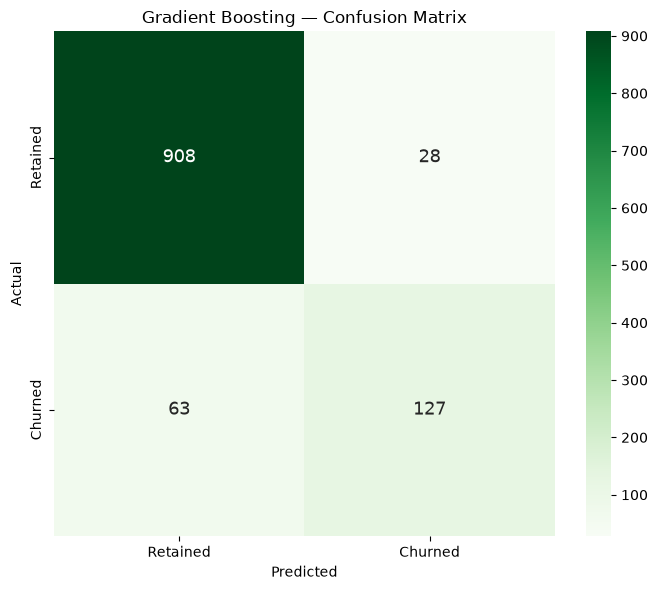

In [82]:
cm_rf = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Retained', 'Churned'],
    yticklabels=['Retained', 'Churned'],
    cbar=True,
    annot_kws={'size': 13}
)

plt.title('Gradient Boosting — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [51]:
# Now comparing all the models with ROC-AUC

from sklearn.metrics import roc_auc_score

print("Logistic Regression", roc_auc_score(y_test, y_pred))
print("Random Forest", roc_auc_score(y_test, y_pred_rf))
print("Gradient Boosting", roc_auc_score(y_test, y_pred_gb))

Logistic Regression 0.7571243814664866
Random Forest 0.9057579847053532
Gradient Boosting 0.8192532613585245


In [52]:
from sklearn.metrics import roc_auc_score

print("Logistic Regression:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1]))
print("Random Forest:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))
print("Gradient Boosting:", roc_auc_score(y_test, gb_model.predict_proba(X_test)[:,1]))

Logistic Regression: 0.8863472784525416
Random Forest: 0.9968061178587495
Gradient Boosting: 0.9443038686459738


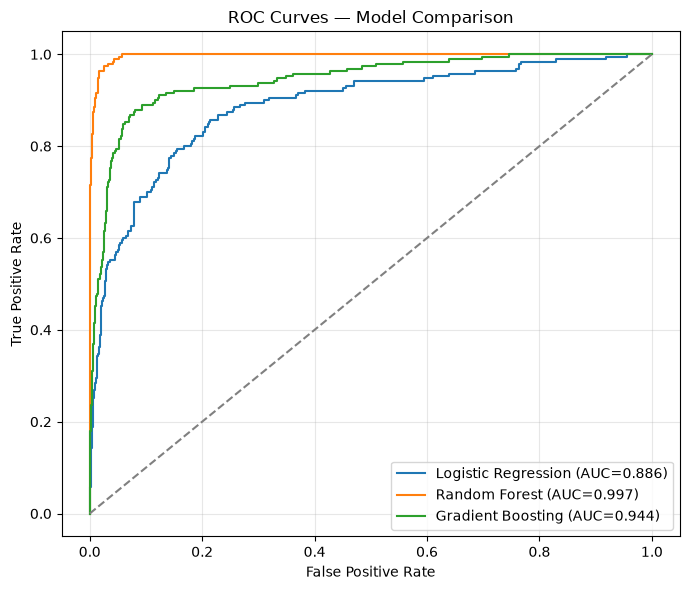

In [71]:
from sklearn.metrics import roc_curve, roc_auc_score

plt.figure(figsize=(7, 6))

# --- Logistic Regression ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, model.predict_proba(X_test_scaled)[:, 1])
auc_lr = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})', color='#1f77b4')

# --- Random Forest ---
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])
auc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})', color='#ff7f0e')

# --- Gradient Boosting ---
fpr_gb, tpr_gb, _ = roc_curve(y_test, gb_model.predict_proba(X_test)[:, 1])
auc_gb = roc_auc_score(y_test, gb_model.predict_proba(X_test)[:, 1])
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={auc_gb:.3f})', color='#2ca02c')

# --- Diagonal reference line (random classifier) ---
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.title('ROC Curves — Model Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()